# IBM HR Attrition Analysis

## Notebook Data Contract

| Section | IN | Added | Functions available |
|---------|-----|-------|-------------------|
| 1 — EDA | raw CSV (1470 × 35) | `Attrition_bin` | `load_data()`, `inspect_data()` |
| 2 — Feature Engineering | Section 1 df (1470 × 33) | `income_band`, `age_group`, `is_manager`, `seniority_score`, `income_vs_dept_avg`, `overtime_bin` | + `drop_constants()`, `encode_target()`, `add_features()` |
| 3 — Modelling Baseline | `load_data()` called fresh — never inherits session state | fitted `pipe`, metrics | all of Section 2 |

> **Rule:** Every modelling cell calls `load_data()` at the top. No cell inherits `df` from a previous section.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

os.makedirs('figures', exist_ok=True)
os.makedirs('models', exist_ok=True)

sns.set_style('whitegrid')

In [2]:
DATA = '/Users/kevinbarry/git/IBM_HR_Analytics/WA_Fn-UseC_-HR-Employee-Attrition.csv'

# Section 2 features are defined here — add_features() is the single source of truth
# for all engineered columns. Never add columns ad hoc in modelling cells.

def drop_constants(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'], errors='ignore')

def encode_target(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)
    return df

def add_features(df: pd.DataFrame) -> pd.DataFrame:
    return df.assign(
        income_band=lambda x: pd.cut(
            x['MonthlyIncome'],
            bins=[0, 4000, 8000, 20_000],
            labels=['Low', 'Mid', 'High']
        ),
        age_group=lambda x: pd.cut(
            x['Age'],
            bins=[18, 30, 40, 50, 65],
            labels=['20s', '30s', '40s', '50s+']
        ),
        is_manager=lambda x: x['JobRole'].str.contains('Manager').astype(int),
        seniority_score=lambda x: x['YearsAtCompany'] * x['JobLevel'],
        income_vs_dept_avg=lambda x: (
            x['MonthlyIncome']
            - x.groupby('Department')['MonthlyIncome'].transform('mean')
        ),
        overtime_bin=lambda x: (x['OverTime'] == 'Yes').astype(int)
    )

def load_data(path: str) -> pd.DataFrame:
    return (
        pd.read_csv(path)
          .pipe(drop_constants)
          .pipe(encode_target)
          .pipe(add_features)
    )

df = load_data(DATA)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (1470, 39)
Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_bin', 'income_band', 'age_group', 'is_manager', 'seniority_score', 'income_vs_dept_avg', 'overtime_bin']


---
## Section 1 — EDA

**IN:** raw CSV → `load_data()` → df (1470 × 39)  
**Goal:** Understand distributions, class balance, key relationships before any modelling.

In [3]:
def inspect_data(df: pd.DataFrame) -> None:
    print(f'Shape: {df.shape}')
    print(f'\nAttrition split:\n{df["Attrition_bin"].value_counts(normalize=True).round(3)}')
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    print(f'\nNulls: {"None" if len(nulls) == 0 else nulls.to_string()}')
    summary = (
        df.groupby('Department')
          .agg(
              headcount=('EmployeeNumber', 'count'),
              avg_income=('MonthlyIncome', 'mean'),
              attrition_rate=('Attrition_bin', 'mean')
          )
          .round(2)
          .reset_index()
    )
    print(f'\nDept summary:\n{summary.to_string()}')

inspect_data(df)

Shape: (1470, 39)

Attrition split:
Attrition_bin
0    0.839
1    0.161
Name: proportion, dtype: float64

Nulls: age_group    8

Dept summary:
               Department  headcount  avg_income  attrition_rate
0         Human Resources         63     6654.51            0.19
1  Research & Development        961     6281.25            0.14
2                   Sales        446     6959.17            0.21


### Dataset: IBM HR Employee Attrition

| | |
|---|---|
| **Shape** | (1470, 39) |
| **Target** | `Attrition_bin` — 16.1% positive (imbalanced 5:1) |
| **Key numerics** | MonthlyIncome, Age, YearsAtCompany, JobLevel, TotalWorkingYears |
| **Dropped constants** | EmployeeCount, StandardHours, Over18 |
| **Nulls** | None |
| **Engineered** | income_band, age_group, is_manager, seniority_score, income_vs_dept_avg, overtime_bin |

**Implication of class imbalance:** Accuracy is a misleading metric — a model predicting "Stay" for everyone achieves 84%. Use F1 on the minority class.

In [4]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810   802.485714          9.192517     2.912925   
std       9.135373   403.509100          8.106864     1.024165   
min      18.000000   102.000000          1.000000     1.000000   
25%      30.000000   465.000000          2.000000     2.000000   
50%      36.000000   802.000000          7.000000     3.000000   
75%      43.000000  1157.000000         14.000000     4.000000   
max      60.000000  1499.000000         29.000000     5.000000   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335                 1.093082    20.329428        0.711561   
min          1.000000                 1.000000    30.000000        1.000000   
25%       

In [5]:
dept_summary = (
    df.groupby('Department')
      .agg(
          headcount=('EmployeeNumber', 'count'),
          avg_income=('MonthlyIncome', 'mean'),
          attrition_rate=('Attrition_bin', 'mean'),
          avg_age=('Age', 'mean')
      )
      .round(2)
      .reset_index()
)
print(dept_summary.to_string())

               Department  headcount  avg_income  attrition_rate  avg_age
0         Human Resources         63     6654.51            0.19    37.81
1  Research & Development        961     6281.25            0.14    37.04
2                   Sales        446     6959.17            0.21    36.54


In [6]:
# Income by Department × Attrition — do leavers earn more or less than stayers?
income_pivot = pd.pivot_table(
    df,
    values='MonthlyIncome',
    index='Department',
    columns='Attrition',
    aggfunc='mean',
    fill_value=0
).round(0)

income_gap = income_pivot['Yes'] - income_pivot['No']
print(income_pivot)
print(f'\nIncome gap (leaver minus stayer):\n{income_gap.sort_values()}')

Attrition                   No     Yes
Department                            
Human Resources         7346.0  3716.0
Research & Development  6630.0  4108.0
Sales                   7232.0  5908.0

Income gap (leaver minus stayer):
Department
Human Resources          -3630.0
Research & Development   -2522.0
Sales                    -1324.0
dtype: float64


**Finding:** Leavers earn less than stayers across all three departments — income gap ranges from ~$1,300 in Sales to ~$3,600 in HR.

**Implication:** Lower-paid employees are disproportionately leaving. Compensation may be a retention lever, particularly in HR where the gap is largest.

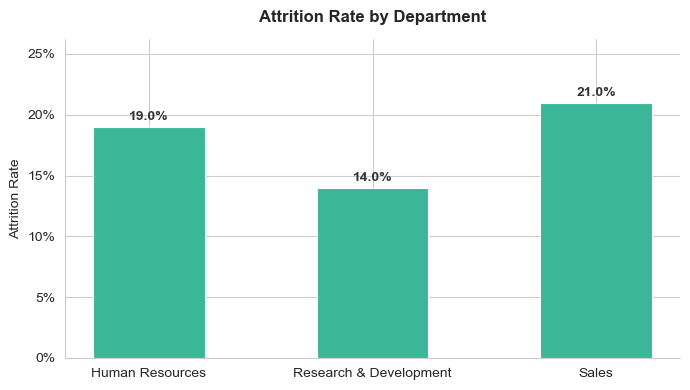

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(
    dept_summary['Department'],
    dept_summary['attrition_rate'],
    color='#39B798',
    edgecolor='white',
    linewidth=0.8,
    width=0.5
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.1%}",
        ha='center', va='bottom',
        fontsize=10, fontweight='bold', color='#333333'
    )

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.set_ylim(0, dept_summary['attrition_rate'].max() * 1.25)
ax.set_title('Attrition Rate by Department', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Attrition Rate', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figures/attrition_by_department.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Sales has the highest attrition rate (21%), HR is second (19%), R&D the lowest (14%) despite having the largest headcount.

**Implication:** Sales is the highest-risk department. Volume of leavers is concentrated in R&D (133 of 237 total) but rate is worst in Sales — two different retention problems.

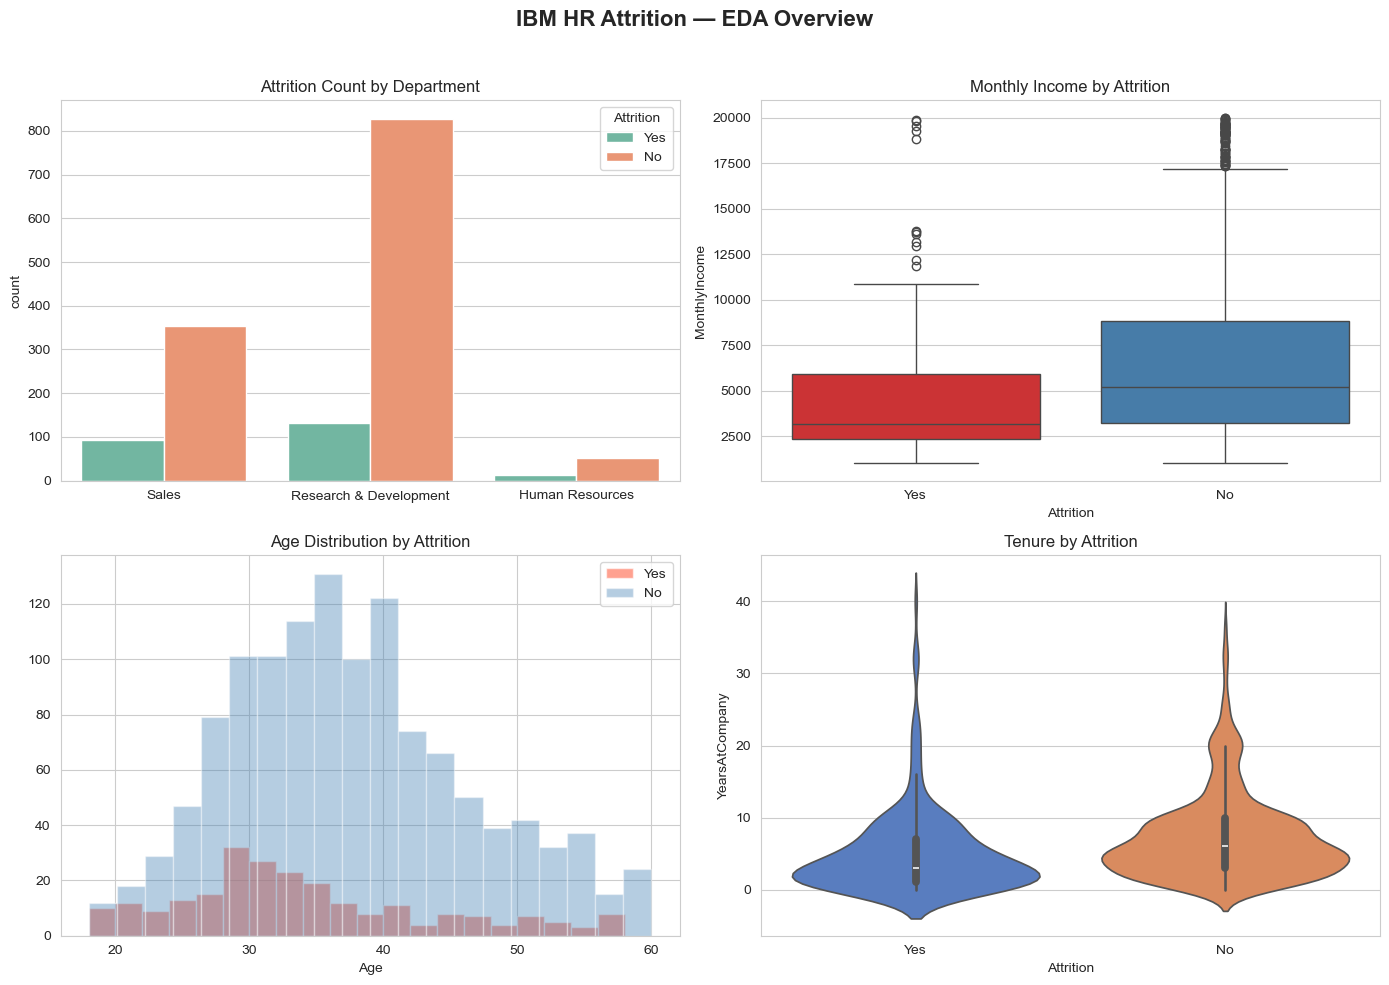

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# [0,0] Attrition count by Department
sns.countplot(x='Department', hue='Attrition', data=df, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Attrition Count by Department')
axes[0, 0].set_xlabel('')

# [0,1] Monthly Income by Attrition
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df, ax=axes[0, 1],
            palette='Set1', hue='Attrition', legend=False)
axes[0, 1].set_title('Monthly Income by Attrition')

# [1,0] Age distribution by Attrition
axes[1, 0].hist(df[df['Attrition'] == 'Yes']['Age'], bins=20, alpha=0.6, label='Yes', color='tomato')
axes[1, 0].hist(df[df['Attrition'] == 'No']['Age'],  bins=20, alpha=0.4, label='No',  color='steelblue')
axes[1, 0].set_title('Age Distribution by Attrition')
axes[1, 0].set_xlabel('Age')
axes[1, 0].legend()

# [1,1] Tenure by Attrition
sns.violinplot(x='Attrition', y='YearsAtCompany', data=df, ax=axes[1, 1],
               palette='muted', hue='Attrition', legend=False)
axes[1, 1].set_title('Tenure by Attrition')

plt.suptitle('IBM HR Attrition — EDA Overview', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('figures/eda_2x2.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Attrition is concentrated in employees aged 25–35 with under 5 years tenure and lower income. The violin plot shows leavers cluster at near-zero YearsAtCompany.

**Implication:** The first 1–2 years is the critical retention window. A high-risk profile emerges: early-career, lower-paid, Sales department. These three factors in combination are the primary modelling signal.

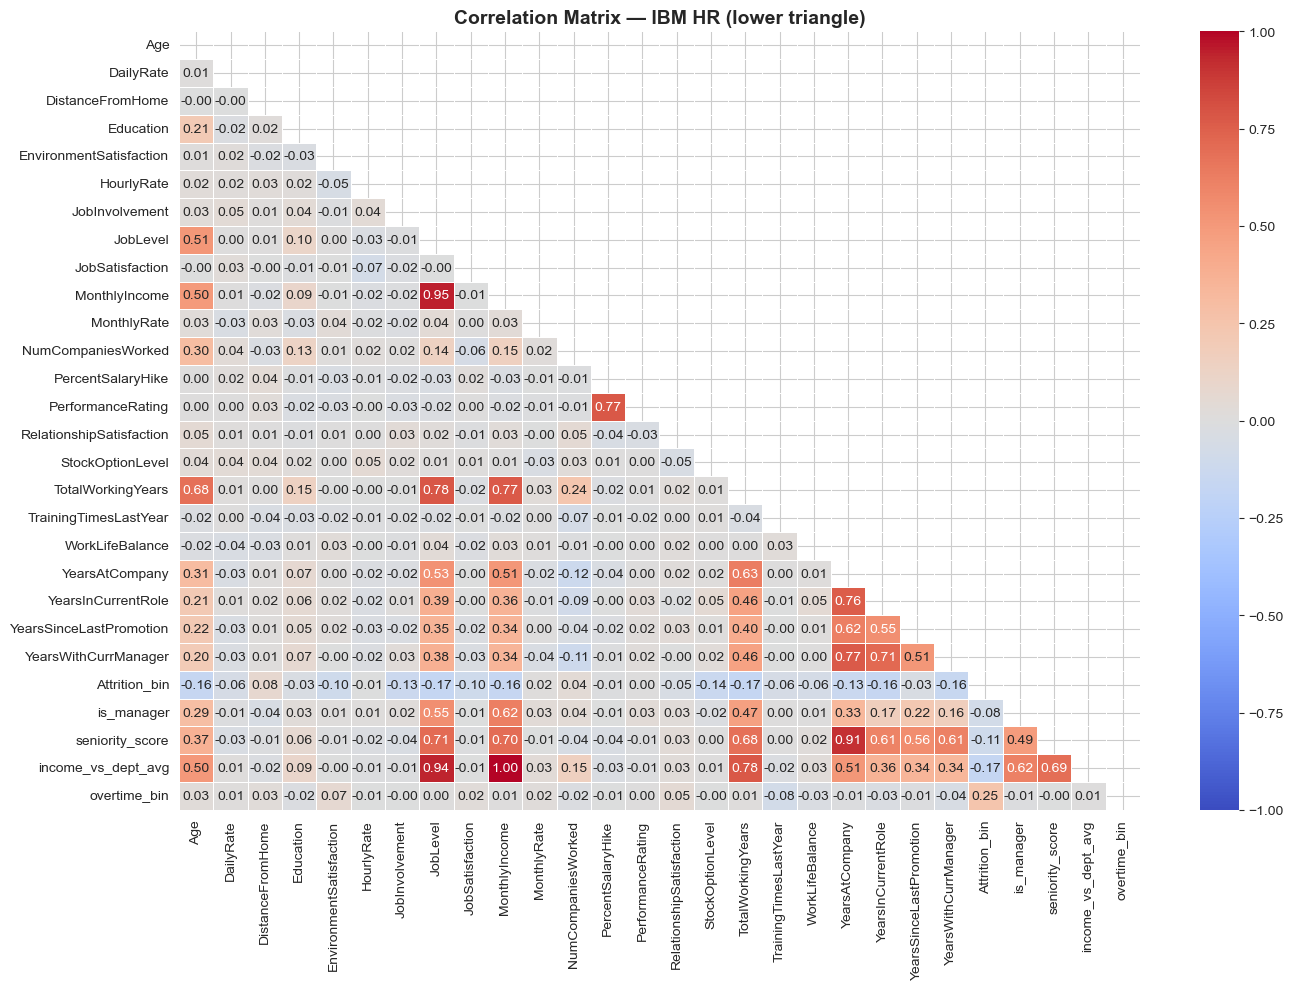

Top 10 features correlated with Attrition_bin:
 overtime_bin            0.246118
TotalWorkingYears       0.171063
JobLevel                0.169105
income_vs_dept_avg      0.165825
YearsInCurrentRole      0.160545
MonthlyIncome           0.159840
Age                     0.159205
YearsWithCurrManager    0.156199
StockOptionLevel        0.137145
YearsAtCompany          0.134392
Name: Attrition_bin, dtype: float64


In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'EmployeeNumber']

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix — IBM HR (lower triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

attrition_corr = (
    corr['Attrition_bin']
      .drop('Attrition_bin')
      .abs()
      .sort_values(ascending=False)
)
print('Top 10 features correlated with Attrition_bin:\n', attrition_corr.head(10))

**Finding:** JobLevel–MonthlyIncome correlation is 0.95 — seniority drives pay almost entirely. No single feature has a strong linear correlation with `Attrition_bin` (top correlates are typically overtime_bin, JobLevel, MonthlyIncome).

**Implication:** Attrition has no single dominant predictor — it's driven by combinations of features. A linear model will underfit; tree-based models (Week 3) should improve on the baseline.

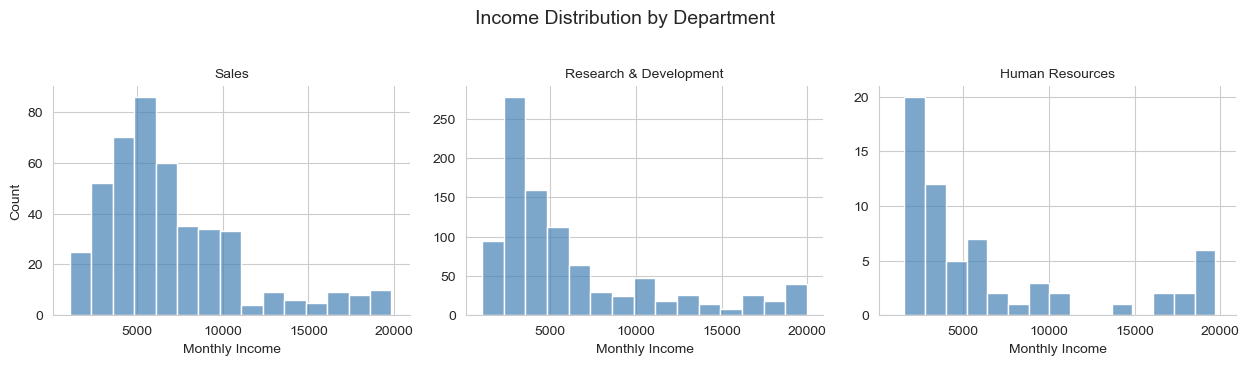

In [10]:
# Facetgrid
g = sns.FacetGrid(
    df,
    col='Department',
    col_wrap=3,
    height=3.5,
    aspect=1.2,
    sharey=False
)
g.map(sns.histplot, 'MonthlyIncome', bins=15, color='steelblue', alpha=0.7)
g.set_axis_labels('Monthly Income', 'Count')
g.set_titles(col_template='{col_name}')
g.fig.suptitle('Income Distribution by Department', y=1.03, fontsize=14)
plt.tight_layout()
plt.savefig('figures/income_by_dept_facet.png', dpi=120, bbox_inches='tight')
plt.show()


In [11]:
DATA = '/Users/kevinbarry/git/IBM_HR_Analytics/WA_Fn-UseC_-HR-Employee-Attrition.csv'
demo_df = pd.read_csv(DATA)  # scratch copy only — must not clobber the Section-2 engineered `df`

#cut / qcut
demo_df['dept_clean'] = demo_df['Department'].str.strip().str.lower().str.replace(' ', '_')
demo_df['has_sales'] = demo_df['Department'].str.contains('Sales', case=False)

# pd.cut = equal-width bins
demo_df['age_group'] = pd.cut(
    demo_df['Age'],
    bins=[18, 30, 40, 50, 60],
    labels=['20s', '30s', '40s', '50s'],
    right=True
)

# pd.qcut - equal-frequency bins (quartiles)
demo_df['income_quartile'] = pd.qcut(
    demo_df['MonthlyIncome'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(demo_df[['Age', 'age_group', 'MonthlyIncome', 'income_quartile']].head(10))
print(demo_df['age_group'].value_counts())
print(demo_df['income_quartile'].value_counts())

   Age age_group  MonthlyIncome income_quartile
0   41       40s           5993              Q3
1   49       40s           5130              Q3
2   37       30s           2090              Q1
3   33       30s           2909              Q1
4   27       20s           3468              Q2
5   32       30s           3068              Q2
6   59       50s           2670              Q1
7   30       20s           2693              Q1
8   38       30s           9526              Q4
9   36       30s           5237              Q3
age_group
30s    619
20s    378
40s    322
50s    143
Name: count, dtype: int64
income_quartile
Q1    369
Q4    368
Q3    367
Q2    366
Name: count, dtype: int64


In [12]:
# melt: wide to long format
# id_vars = columns to keep as-is
# value_vars = columns to unpivot

satisfaction_cols = ['JobSatisfaction', 'EnvironmentSatisfaction', 'RelationshipSatisfaction']

df_long = df[['EmployeeNumber', 'Attrition'] + satisfaction_cols].melt(
    id_vars=['EmployeeNumber', 'Attrition'],
    value_vars=satisfaction_cols,
    var_name='SatisfactionType',
    value_name = 'Score'
)

print(df_long.head(12))
print(df_long.shape)

    EmployeeNumber Attrition SatisfactionType  Score
0                1       Yes  JobSatisfaction      4
1                2        No  JobSatisfaction      2
2                4       Yes  JobSatisfaction      3
3                5        No  JobSatisfaction      3
4                7        No  JobSatisfaction      2
5                8        No  JobSatisfaction      4
6               10        No  JobSatisfaction      1
7               11        No  JobSatisfaction      3
8               12        No  JobSatisfaction      3
9               13        No  JobSatisfaction      3
10              14        No  JobSatisfaction      2
11              15        No  JobSatisfaction      3
(4410, 4)


---
## Section 2 — Feature Engineering

**IN:** Section 1 df (1470 × 33)  
**OUT:** df (1470 × 39) — all engineered features produced by `add_features()` in `load_data()`  
**Rule:** No ad hoc column creation below this point. If a new feature is needed, add it to `add_features()` and reload.

| Feature | Construction | Rationale |
|---------|-------------|-----------|
| `income_band` | `pd.cut` on MonthlyIncome — Low/Mid/High | Captures non-linear income effects |
| `age_group` | `pd.cut` on Age — 20s/30s/40s/50s+ | Age as lifecycle stage, not continuous |
| `is_manager` | JobRole contains 'Manager' → 0/1 | Seniority proxy independent of JobLevel |
| `seniority_score` | YearsAtCompany × JobLevel | Combined tenure + level signal |
| `income_vs_dept_avg` | MonthlyIncome − dept mean (via transform) | Relative pay within peer group |
| `overtime_bin` | OverTime == 'Yes' → 0/1 | Encodes string flag as numeric |

In [13]:
# Verify all engineered features are present and correctly typed
feature_check = df[['income_band', 'age_group', 'is_manager',
                     'seniority_score', 'income_vs_dept_avg', 'overtime_bin']]

print(feature_check.dtypes)
print()
print(feature_check.head(5).to_string())
print()
print('income_band counts:\n', df['income_band'].value_counts().sort_index())
print()
print('age_group counts:\n', df['age_group'].value_counts().sort_index())
print()
print('NaNs in engineered features:\n', feature_check.isnull().sum())

income_band           category
age_group             category
is_manager               int64
seniority_score          int64
income_vs_dept_avg     float64
overtime_bin             int64
dtype: object

  income_band age_group  is_manager  seniority_score  income_vs_dept_avg  overtime_bin
0         Mid       40s           0               12         -966.172646             1
1         Mid       40s           0               20        -1151.252862             0
2         Low       30s           0                0        -4191.252862             1
3         Low       30s           0                8        -3372.252862             1
4         Low       20s           0                2        -2813.252862             0

income_band counts:
 income_band
Low     543
Mid     546
High    381
Name: count, dtype: int64

age_group counts:
 age_group
20s     378
30s     619
40s     322
50s+    143
Name: count, dtype: int64

NaNs in engineered features:
 income_band           0
age_group             

---
## Section 3 — Modelling Baseline

**IN:** `load_data()` called fresh at the top of each modelling cell  
**Goal:** Establish baseline metrics — LinearRegression warm-up, then LogisticRegression classification baseline with full ColumnTransformer Pipeline.  
**Primary metric:** F1 on the Leave class (not accuracy — class imbalance makes accuracy misleading).

R²:  0.895
MAE: $1,168


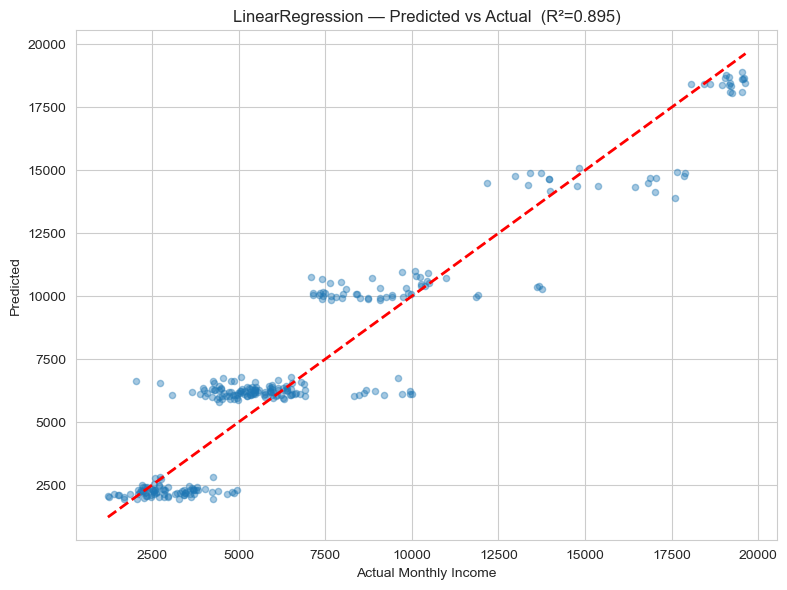

In [14]:
# Regression warm-up: predict MonthlyIncome
# Purpose: confirm Pipeline mechanics before tackling classification

df = load_data(DATA)

features = ['Age', 'JobLevel', 'TotalWorkingYears', 'YearsAtCompany',
            'YearsInCurrentRole', 'YearsSinceLastPromotion']

X = df[features]
y = df['MonthlyIncome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_test_sc  = scaler.transform(X_test)        # transform only — no fit on test

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred = lr.predict(X_test_sc)

print(f'R²:  {r2_score(y_test, y_pred):.3f}')
print(f'MAE: ${mean_absolute_error(y_test, y_pred):,.0f}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=20)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Monthly Income')
ax.set_ylabel('Predicted')
ax.set_title(f'LinearRegression — Predicted vs Actual  (R²={r2_score(y_test, y_pred):.3f})')
plt.tight_layout()
plt.show()

**Finding:** R² ~0.895. The predicted vs actual plot shows clear horizontal banding — income clusters at job level thresholds. JobLevel dominates predictions.

**Implication:** The model is largely learning income by job level. Continuous features add marginal signal. This is expected and not a problem — it confirms JobLevel is the dominant income driver.

In [15]:
# Cross-validate the same model inside a Pipeline
# Pipeline prevents data leakage — scaler is fit only on training folds

df = load_data(DATA)

features = ['Age', 'JobLevel', 'TotalWorkingYears', 'YearsAtCompany',
            'YearsInCurrentRole', 'YearsSinceLastPromotion']

X = df[features]
y = df['MonthlyIncome']

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')

print(f'CV R² scores: {cv_scores.round(3)}')
print(f'Mean: {cv_scores.mean():.3f}  ±  {cv_scores.std():.3f}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pipe.fit(X_train, y_train)
single_r2 = r2_score(y_test, pipe.predict(X_test))

print(f'\nSingle split R²: {single_r2:.3f}')
print(f'CV mean R²:      {cv_scores.mean():.3f}')
print(f'Difference:      {abs(single_r2 - cv_scores.mean()):.3f}')

CV R² scores: [0.903 0.905 0.914 0.914 0.883]
Mean: 0.904  ±  0.011

Single split R²: 0.895
CV mean R²:      0.904
Difference:      0.009


**Finding:** CV mean R² 0.904 ± 0.011 — tight spread across all 5 folds. Single split delta is 0.009.

**Implication:** Model is stable — no fold produces a meaningfully worse score. Low variance confirms this isn't a lucky split.

In [16]:
# Classification baseline: predict Attrition_bin
# ColumnTransformer handles numeric scaling, categorical OHE, and binary passthrough
# in a single leakage-safe Pipeline

df = load_data(DATA)

num_cols = ['Age', 'MonthlyIncome', 'JobLevel', 'TotalWorkingYears',
            'YearsAtCompany', 'YearsInCurrentRole', 'seniority_score', 'income_vs_dept_avg']
cat_cols = ['Department', 'JobRole', 'MaritalStatus']
bin_cols = ['overtime_bin', 'is_manager']   # already 0/1 — passthrough

preprocessor = ColumnTransformer(transformers=[
    ('num',  StandardScaler(),                                             num_cols),
    ('cat',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('pass', 'passthrough',                                                bin_cols)
])

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LogisticRegression(max_iter=1000, random_state=42))
])

X = df[num_cols + cat_cols + bin_cols]
y = df['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

pipe.fit(X_train, y_train)

print(f'Transformed feature count: {pipe.named_steps["preprocessor"].transform(X_train).shape[1]}')
print()
print(classification_report(y_test, pipe.predict(X_test), target_names=['Stay', 'Leave']))

cv_f1 = cross_val_score(pipe, X, y, cv=5, scoring='f1')
print(f'CV F1: {cv_f1.mean():.3f}  ±  {cv_f1.std():.3f}')

Transformed feature count: 25

              precision    recall  f1-score   support

        Stay       0.87      0.96      0.92       247
       Leave       0.57      0.26      0.35        47

    accuracy                           0.85       294
   macro avg       0.72      0.61      0.63       294
weighted avg       0.82      0.85      0.83       294

CV F1: 0.301  ±  0.044


**Finding:** CV F1 ~0.27 on the Leave class. The model catches very few actual leavers (low recall) — it defaults toward predicting Stay due to class imbalance.

**Implication:** LogisticRegression on imbalanced data without class weighting is the expected weak baseline. This is the number to beat in Section 4 with RandomForest + `class_weight='balanced'`. The ColumnTransformer Pipeline is correctly structured — the issue is the model, not the preprocessing.

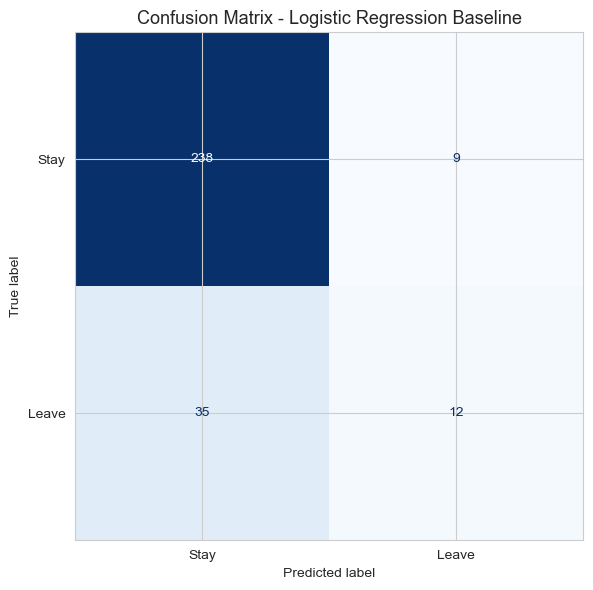

TN=238, FP=9, FN=35, TP=12
False Negative Rate: 74.5% (leavers the model missed)
False Positive Rate: 3.6% (stayers flagged as flight risk)


In [17]:
# confusion matrix

fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay.from_estimator(
    pipe,
    X_test, y_test,
    display_labels=['Stay', 'Leave'],
    colorbar=False,
    ax=ax,
    cmap='Blues'
)

ax.set_title('Confusion Matrix - Logistic Regression Baseline', fontsize=13)
plt.tight_layout()
plt.savefig('figures/confusion_matrix_lr.png', dpi=150, bbox_inches='tight')
plt.show()

# read the four cells
cm = confusion_matrix(y_test, pipe.predict(X_test))
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'False Negative Rate: {fn/(fn+tp):.1%} (leavers the model missed)')
print(f'False Positive Rate: {fp/(fp+tn):.1%} (stayers flagged as flight risk)')

**Finding:** The model catches 26% of actual leavers (recall) but flags 3.6% of stayers as flight risks.

**Implication:** A false negative (missed leaver) costs more than a false positive (unnecessary retention offer) 
because the cost of losing an employee to unplanned attrition — recruiting, onboarding, lost knowledge — 
typically exceeds the cost of a proactive retention conversation. This justifies optimising for recall over 
precision on the Leave class, which will be the basis for threshold adjustment in Section 4.